<a href="https://colab.research.google.com/github/eemaansheikh/Data_Science_2025/blob/main/EemaanSheikh__Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

* Not all relationships are perfectly linear; a polynomial model captures curvature of the relationship and increases the graph's flexibility to the data set.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

* Since polynomials are geared toward increasing a models fit, a potential drawback is overfitting and resulting inaccuracy of the fit.

**Task3**:

What's the point of using b splines?



*   b-splines get the flexibility aspect of a polynomial while reducing the risk of overfitting.



**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

* The gaussian process shows the correlation between each point of data (like a high correlation between x values that are close together?) to create a function that covers every possible value in the data set and strongly represents the dataset.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [26]:
!pip install preliz
!pip install bambi

In [28]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator
import bambi as bmb
import preliz as pz

In [18]:
#downloads the data from my github
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
#degree 4 polynomial model
model_poly_3 = bmb.Model("weight ~ poly(height, degree=3)", howell, family="negativebinomial")
idata_poly_3 = model_poly_3.fit()

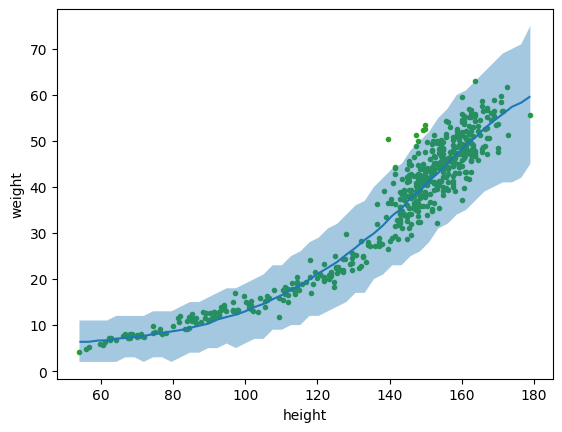

In [6]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_3, idata_poly_3, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
num_knots = 6
knots = np.linspace(howell.height.min(), howell.height.max(), num_knots+2)[1:-1]
model_spline_t = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline_t = model_spline_t.fit()

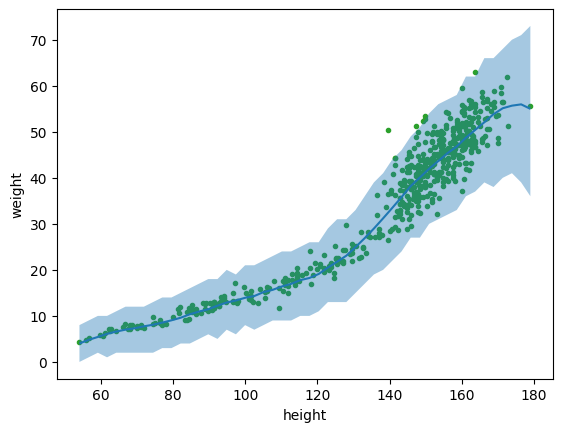

In [9]:
bmb.interpret.plot_predictions(model_spline_t, idata_spline_t, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [21]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    # Convert x_vals to a NumPy array to avoid NotImplementedError with np.subtract.outer
    x_vals_array = np.asarray(x_vals)
    differences = np.abs(np.subtract.outer(x_vals_array, x_vals_array))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(howell.height))
}

priors = {
    "hsgp(height, m=168, c=8.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("weight ~ 0 + hsgp(height, m=168, c=8.0)", howell, family="negativebinomial", priors=priors)
idata_hsb = model_hsb.fit()

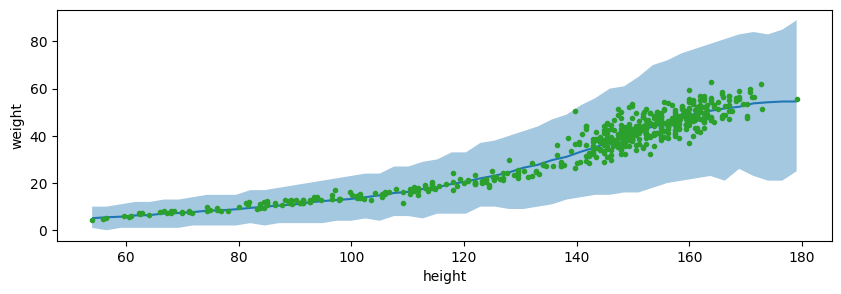

In [30]:
_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values, howell["weight"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

GPs can be represented through a mean function or as a covariance function. the mean function just finds the average (mean) of the curves (i think?) and the covariance function is a combination (sum/product) of multiple functions that change the shape of the curve at different changepoints.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

I liked the posterior predictive model for CO2 given the year. The test set data matched incredibly well with the samples from the posterior, even given all the changepoints.